In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn sentence-transformers tqdm

  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 570.8/570.8 kB 16.2 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 19.4 MB/s  0:00:00eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 11.5 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.6/80.6 MB 5.1 MB/s  0:00:15m0:00:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 1.3 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 1.5 MB/s  0:00:01 eta 0:00:01
Using cached sympy-1.14.0-py3-none-any.whl (6.3 MB)
Using cached mpmath-1.3.0-py3-none-any.whl (536 kB)
  Attempting uninstall: setuptools━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/10 [sympy]
    Found existing installation: setuptools 82.0.0━━━━━━━━━━━━  1/10 [sympy]
    Uninstalling setuptools-82.0.0:━━━━━━━━━━━━━━━━━━━━━━━━━━━  1/10 [sympy]
      Successfully uninsta

In [25]:
import pandas as pd
import numpy as np
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

sns.set(style="whitegrid")

In [5]:
df = pd.read_csv("../data/bank_sentences.csv")
df.head()

,Number,Type,Sentence
0,1,Financial Bank,She deposited her paycheck at the bank on Frid...
1,2,Financial Bank,The bank approved her mortgage application aft...
2,3,Financial Bank,He stood in line at the bank for nearly thirty...
3,4,Financial Bank,The central bank raised interest rates to comb...
4,5,Financial Bank,My bank sent me a fraud alert about a suspicio...


In [14]:
model = SentenceTransformer("all-MiniLM-L6-v2")

sentences = df["Sentence"].tolist()
embeddings = model.encode(sentences, show_progress_bar=True)

df["embedding"] = list(embeddings)
df.head()

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/4 [00:00<?, ?it/s]

,Number,Type,Sentence,embedding
0,1,Financial Bank,She deposited her paycheck at the bank on Frid...,"[0.022515465, 0.05161872, -0.01657425, 0.03342..."
1,2,Financial Bank,The bank approved her mortgage application aft...,"[0.016132781, 0.011006355, -0.04363128, -0.018..."
2,3,Financial Bank,He stood in line at the bank for nearly thirty...,"[0.03155625, 0.07585106, -0.08801351, -0.04343..."
3,4,Financial Bank,The central bank raised interest rates to comb...,"[0.004830261, -0.023992192, -0.09268176, 0.030..."
4,5,Financial Bank,My bank sent me a fraud alert about a suspicio...,"[0.048719995, 0.03511519, -0.037372507, 0.0162..."


In [17]:
river_embs = np.vstack(df[df["Type"] == "River Bank"]["embedding"])
finance_embs = np.vstack(df[df["Type"] == "Financial Bank"]["embedding"])

river_mean = river_embs.mean(axis=0)
finance_mean = finance_embs.mean(axis=0)

In [22]:
# Candidate vocabulary (can expand!)
vocab = [
    "money", "cash", "loan", "finance", "river", "water",
    "shore", "stream", "investment", "credit", "mud",
    "sand", "flow", "account", "deposit", "nature"
]

vocab_embs = model.encode(vocab)

In [45]:
# Cosine sim:
def top_k_similar(target_vec, vocab, vocab_embs, k=5):
    sims = cosine_similarity([target_vec], vocab_embs)[0]
    idx = np.argsort(sims)[::-1][:k]
    return [(vocab[i], sims[i]) for i in idx]

# Distance:
def top_k_closest(target_vec, vocab, vocab_embs, k=5):
    dists = np.linalg.norm(vocab_embs - target_vec, axis=1)
    idx = np.argsort(dists)[:k]
    return [(vocab[i], dists[i]) for i in idx]

In [ ]:
print("River sense:")
print(top_k_similar(river_mean, vocab, vocab_embs))

print("\nFinance sense:")
print(top_k_similar(finance_mean, vocab, vocab_embs))

River sense:
[('river', np.float32(0.53038406)), ('deposit', np.float32(0.31832024)), ('cash', np.float32(0.29230052)), ('loan', np.float32(0.26829618)), ('flow', np.float32(0.2615655))]

River sense (closest):
[('river', np.float32(0.8491464)), ('deposit', np.float32(0.9831535)), ('cash', np.float32(0.9983578)), ('loan', np.float32(1.0121819)), ('flow', np.float32(1.0160242))]

Finance sense:
[('finance', np.float32(0.48109472)), ('deposit', np.float32(0.47686958)), ('loan', np.float32(0.47576627)), ('cash', np.float32(0.45341533)), ('account', np.float32(0.36205247))]

Finance sense (closest):
[('finance', np.float32(0.8819464)), ('deposit', np.float32(0.8847085)), ('loan', np.float32(0.88542825)), ('cash', np.float32(0.8998865)), ('account', np.float32(0.9567174))]


In [ ]:
all_embs = np.vstack(df["embedding"])

pca = PCA(n_components=2)
reduced = pca.fit_transform(all_embs)

df["pc1"] = reduced[:, 0]
df["pc2"] = reduced[:, 1]


vocab_reduced = pca.transform(vocab_embs)

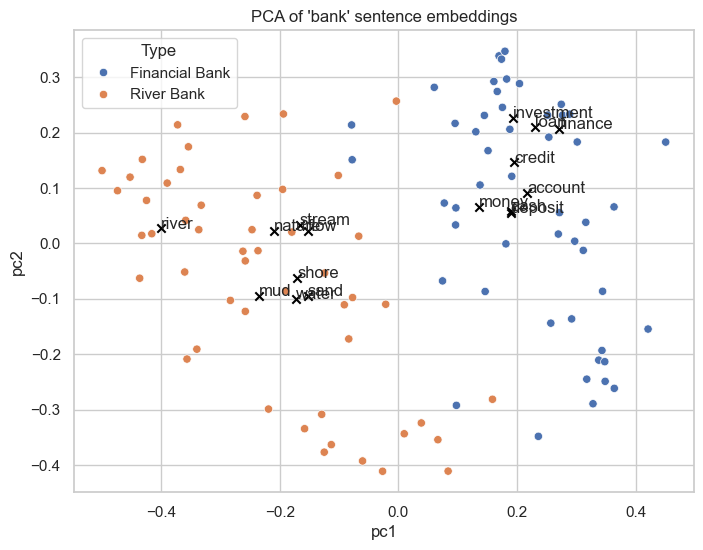

In [36]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x="pc1", y="pc2", hue="Type")
# Vocab points (overlay)
plt.scatter(vocab_reduced[:, 0], vocab_reduced[:, 1], marker="x", color="black", label="Vocab")
# Add labels for vocab
for i, word in enumerate(vocab):
    plt.text(vocab_reduced[i, 0], vocab_reduced[i, 1], word)
plt.title("PCA of 'bank' sentence embeddings")
plt.show()

In [37]:
quiet = model.encode([
    "a calm river bank",
    "a peaceful river edge"
]).mean(axis=0)

hectic = model.encode([
    "a busy crowded river bank",
    "a noisy river side"
]).mean(axis=0)

river_activity_dim = hectic - quiet
